In [1]:
!python --version

Python 3.12.10


In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Практичне завдання №2: Відновлення дискретизованого сигналу
## Варіант 10 (парний)

### 1. ПАРАМЕТРИ СИГНАЛУ ТА МОДУЛЯЦІЇ

In [3]:
B_NUMBER = 10                  # Варіант

f_carrier = 50 + B_NUMBER      # Несуча частота (Hz)
A_c = 1.0                      # Амплітуда
f_audio = 5.0                  # Частота аудіосигналу (Hz)
delta_f = 20.0                 # Пікова частота девіації (Hz)
duration = 1.0                 # Тривалість 1 секунда

### 2. РОЗРАХУНОК ЧАСТОТ ДИСКРЕТИЗАЦІЇ

In [4]:
# Частота дискретизації за Карсоном
f_sampling = 2 * (f_carrier + delta_f + f_audio)
t_sampled = np.arange(0, duration, 1 / f_sampling)

# Частота для відновленого (щільного) сигналу
f_dense = 10 * f_sampling
t_dense = np.arange(0, duration, 1 / f_dense)

print(f"Несуча частота (f_carrier): {f_carrier} Hz")
print(f"Частота дискретизації за Карсоном (f_sampling): {f_sampling} Hz")
print(f"Частота для відновлення (10 * f_sampling): {f_dense} Hz")

Несуча частота (f_carrier): 60 Hz
Частота дискретизації за Карсоном (f_sampling): 170.0 Hz
Частота для відновлення (10 * f_sampling): 1700.0 Hz


### 3. ГЕНЕРАЦІЯ СИГНАЛІВ

In [5]:
# Аудіосигнал (для візуалізації)
audio_dense = np.sin(2 * np.pi * f_audio * t_dense)

# Дискретизований ЧМ-сигнал згідно з рівнянням із завдання
s_fm_sampled = A_c * np.cos(
    2 * np.pi * f_carrier * t_sampled +
    (delta_f / f_audio) * np.sin(2 * np.pi * f_audio * t_sampled)
)

### 4. ВІДНОВЛЕННЯ СИГНАЛУ (Інтерполяція Шеннона)

In [6]:
s_fm_reconstructed = np.zeros_like(t_dense)

# Відновлення сумою кардинальних синусів (sinc)
# np.sinc(x) в numpy реалізовано як sin(pi*x)/(pi*x), тому множити на pi не потрібно
for n, sample in enumerate(s_fm_sampled):
    s_fm_reconstructed += sample * np.sinc(t_dense * f_sampling - n)

## Візуалізація результатів

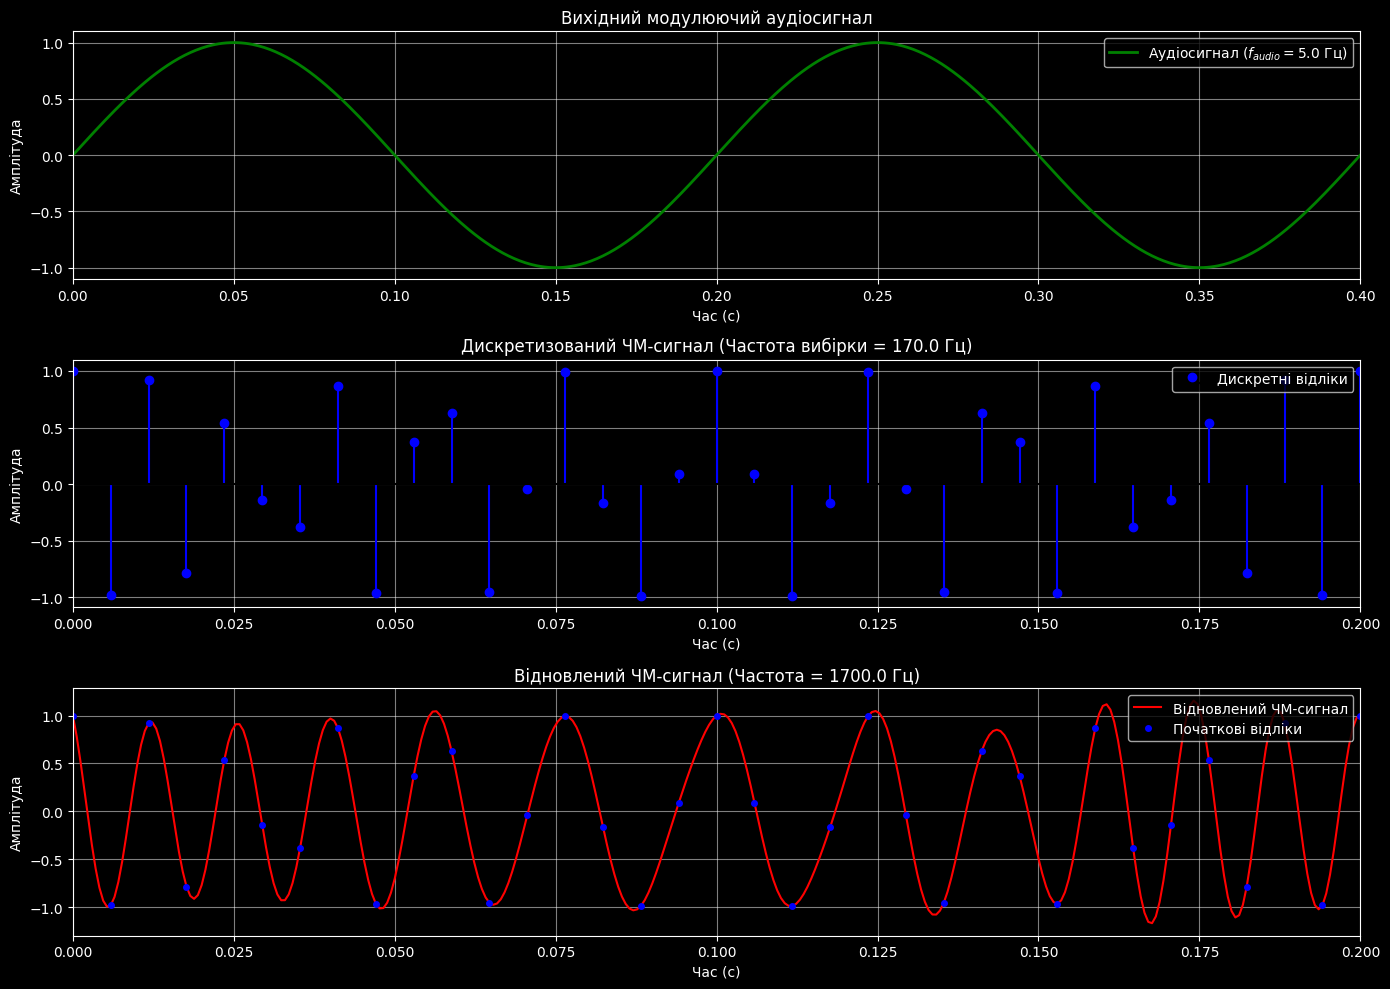

In [7]:
plt.figure(figsize=(14, 10))

# Графік 1: Аудіосигнал
plt.subplot(3, 1, 1)
plt.plot(t_dense, audio_dense, 'g', linewidth=2, label=f'Аудіосигнал ($f_{{audio}}={f_audio}$ Гц)')
plt.title('Вихідний модулюючий аудіосигнал')
plt.xlabel('Час (с)')
plt.ylabel('Амплітуда')
plt.grid(True, alpha=0.5)
plt.legend(loc='upper right')
plt.xlim(0, 0.4)  # Показуємо 2 періоди (2 * 1/5 = 0.4с)

# Графік 2: Дискретизований ЧМ-сигнал
plt.subplot(3, 1, 2)
plt.stem(t_sampled, s_fm_sampled, linefmt='b-', markerfmt='bo', basefmt='k-', label='Дискретні відліки')
plt.title(f'Дискретизований ЧМ-сигнал (Частота вибірки = {f_sampling} Гц)')
plt.xlabel('Час (с)')
plt.ylabel('Амплітуда')
plt.grid(True, alpha=0.5)
plt.legend(loc='upper right')
plt.xlim(0, 0.2)  # Збільшуємо масштаб для чіткості відліків

# Графік 3: Відновлений ЧМ-сигнал
plt.subplot(3, 1, 3)
plt.plot(t_dense, s_fm_reconstructed, 'r-', linewidth=1.5, label='Відновлений ЧМ-сигнал')
plt.plot(t_sampled, s_fm_sampled, 'bo', markersize=4, label='Початкові відліки')
plt.title(f'Відновлений ЧМ-сигнал (Частота = {f_dense} Гц)')
plt.xlabel('Час (с)')
plt.ylabel('Амплітуда')
plt.grid(True, alpha=0.5)
plt.legend(loc='upper right')
plt.xlim(0, 0.2)

plt.tight_layout()
plt.show()